In [1]:
# ── Core libraries ─────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Display settings ─────────────────────────────────────────
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("All imports successful ✅")

All imports successful ✅


In [2]:
df = pd.read_csv('../data/attrition.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-nul

In [4]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found ✅")

MISSING VALUES
No missing values found ✅


In [5]:
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

DUPLICATE ROWS
Number of duplicate rows: 0


In [6]:
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe().T

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


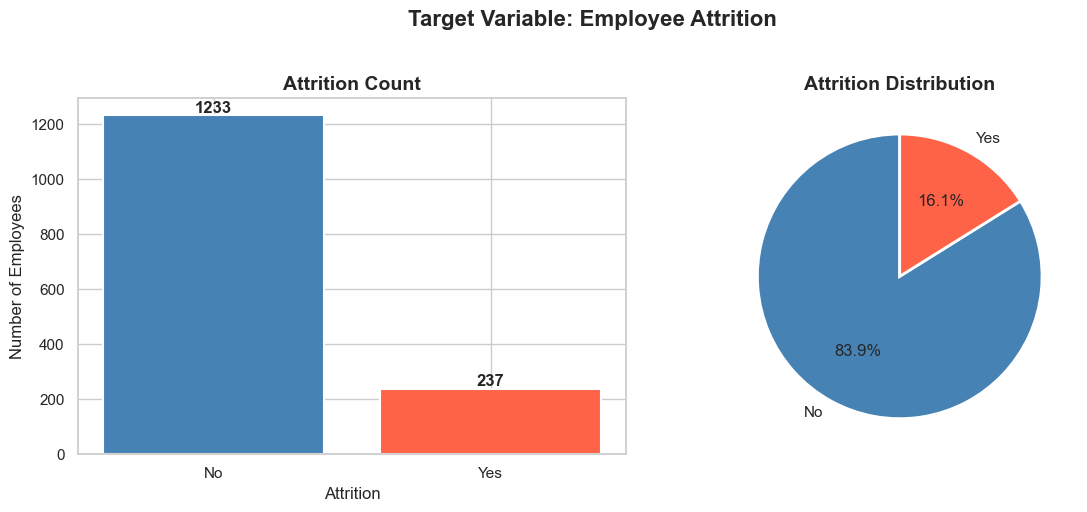

In [7]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Attrition Counts:")
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_pct['Yes']:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(attrition_counts.index, attrition_counts.values, 
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Employee Attrition', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/attrition_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Separate columns by data type
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")

Numerical columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\USER\AppData\Local\Temp\ipykernel_34676\729723625.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [9]:
# These columns have zero variance - same value for every employee
print("Unique values in constant columns:")
print(f"StandardHours: {df['StandardHours'].unique()}")
print(f"Over18: {df['Over18'].unique()}")
print(f"EmployeeCount: {df['EmployeeCount'].unique()}")

# Also EmployeeNumber is just an ID - not useful for prediction
print(f"EmployeeNumber sample: {df['EmployeeNumber'].head().values}")

Unique values in constant columns:
StandardHours: [80]
Over18: <ArrowStringArray>
['Y']
Length: 1, dtype: str
EmployeeCount: [1]
EmployeeNumber sample: [1 2 4 5 7]


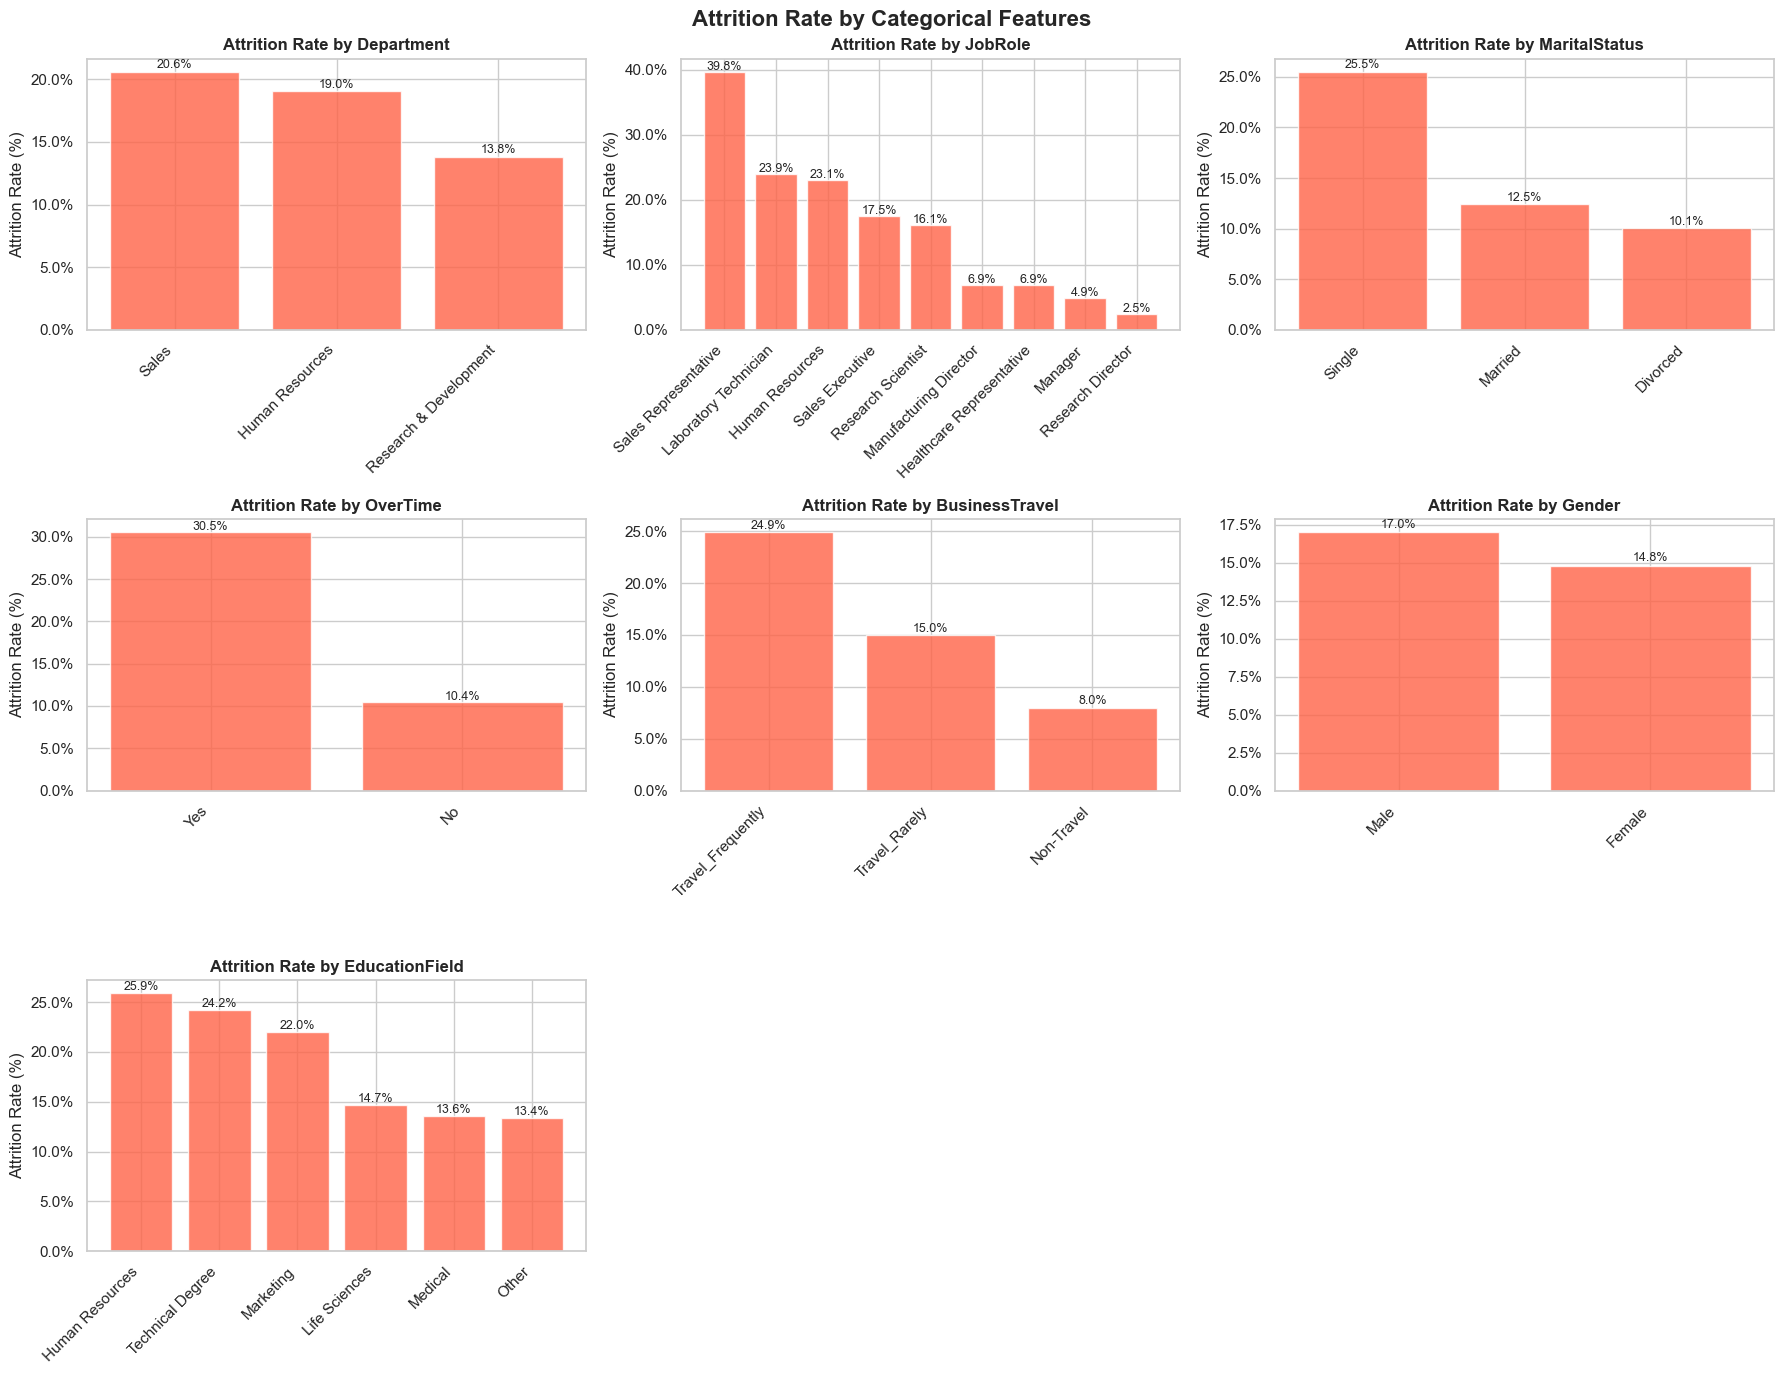

In [10]:
cat_features = ['Department', 'JobRole', 'MaritalStatus', 
                'OverTime', 'BusinessTravel', 'Gender', 'EducationField']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)

    bars = axes[i].bar(attrition_rate.index, attrition_rate.values,
                       color='tomato', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Attrition Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xticks(range(len(attrition_rate.index)))
    axes[i].set_xticklabels(attrition_rate.index, rotation=45, ha='right')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, attrition_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

# Hide unused subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.suptitle('Attrition Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/attrition_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

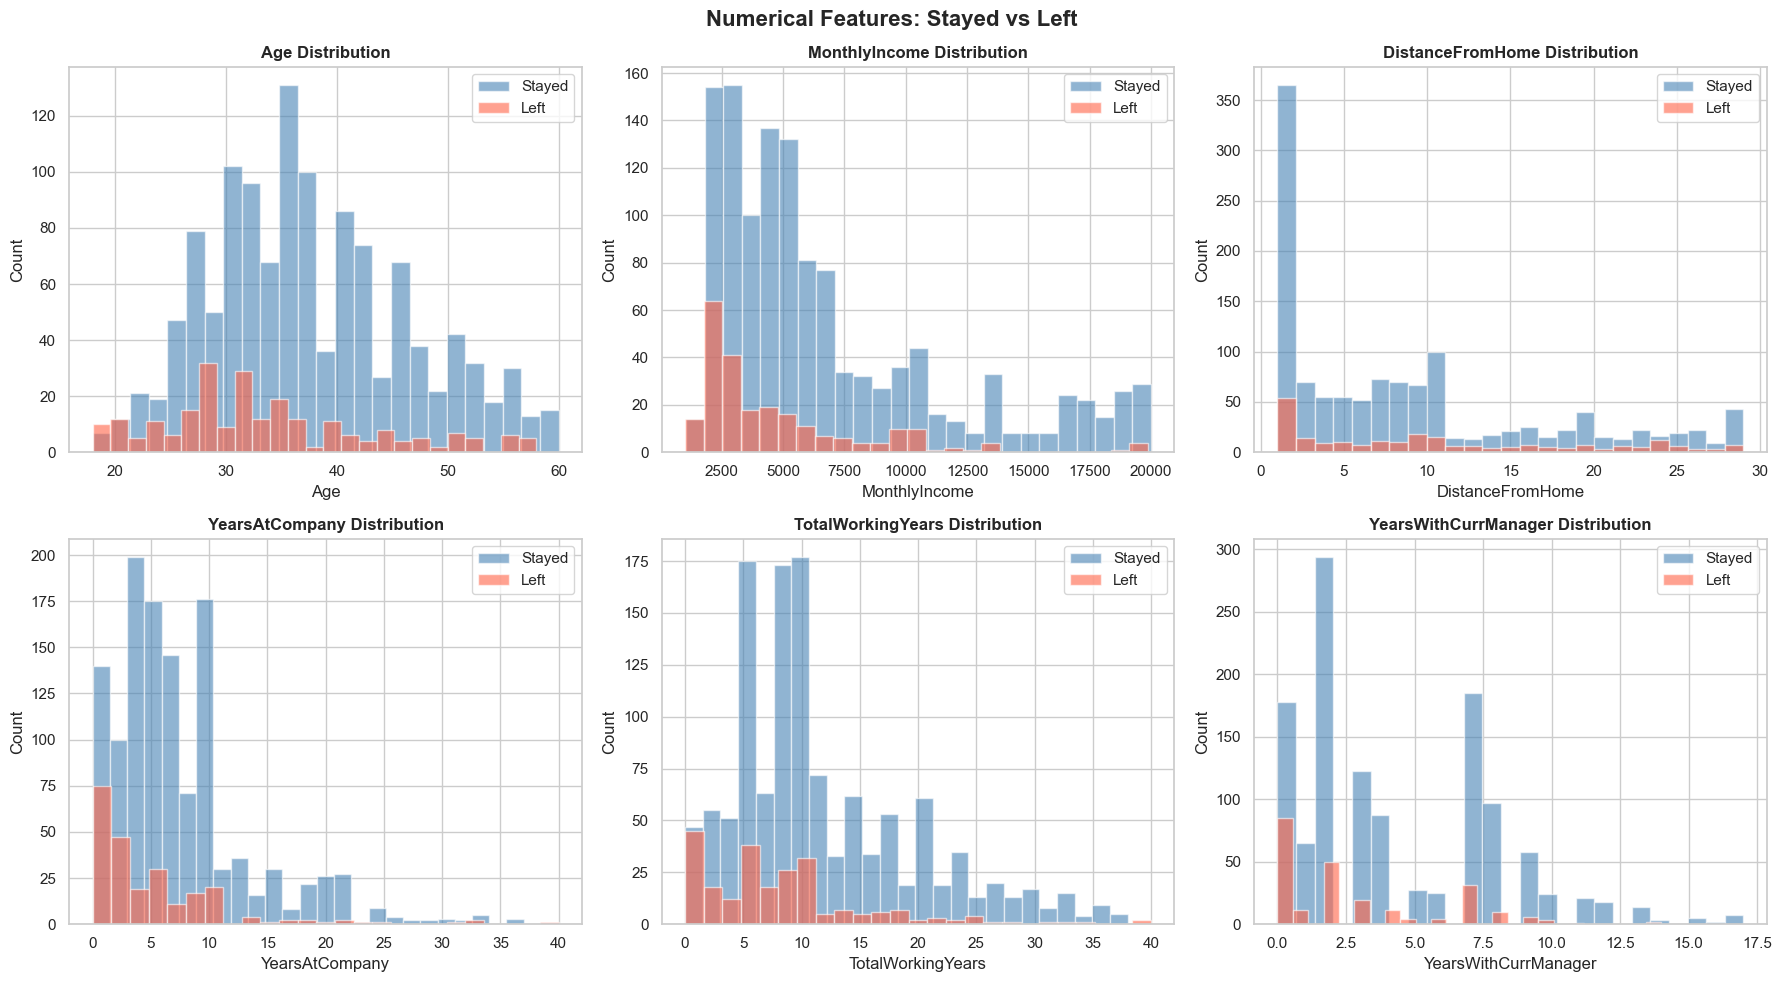

In [11]:
num_features = ['Age', 'MonthlyIncome', 'DistanceFromHome',
                'YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    stayed = df[df['Attrition'] == 'No'][col]
    left = df[df['Attrition'] == 'Yes'][col]

    axes[i].hist(stayed, bins=25, alpha=0.6, label='Stayed', color='steelblue', edgecolor='white')
    axes[i].hist(left, bins=25, alpha=0.6, label='Left', color='tomato', edgecolor='white')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Numerical Features: Stayed vs Left', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/attrition_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

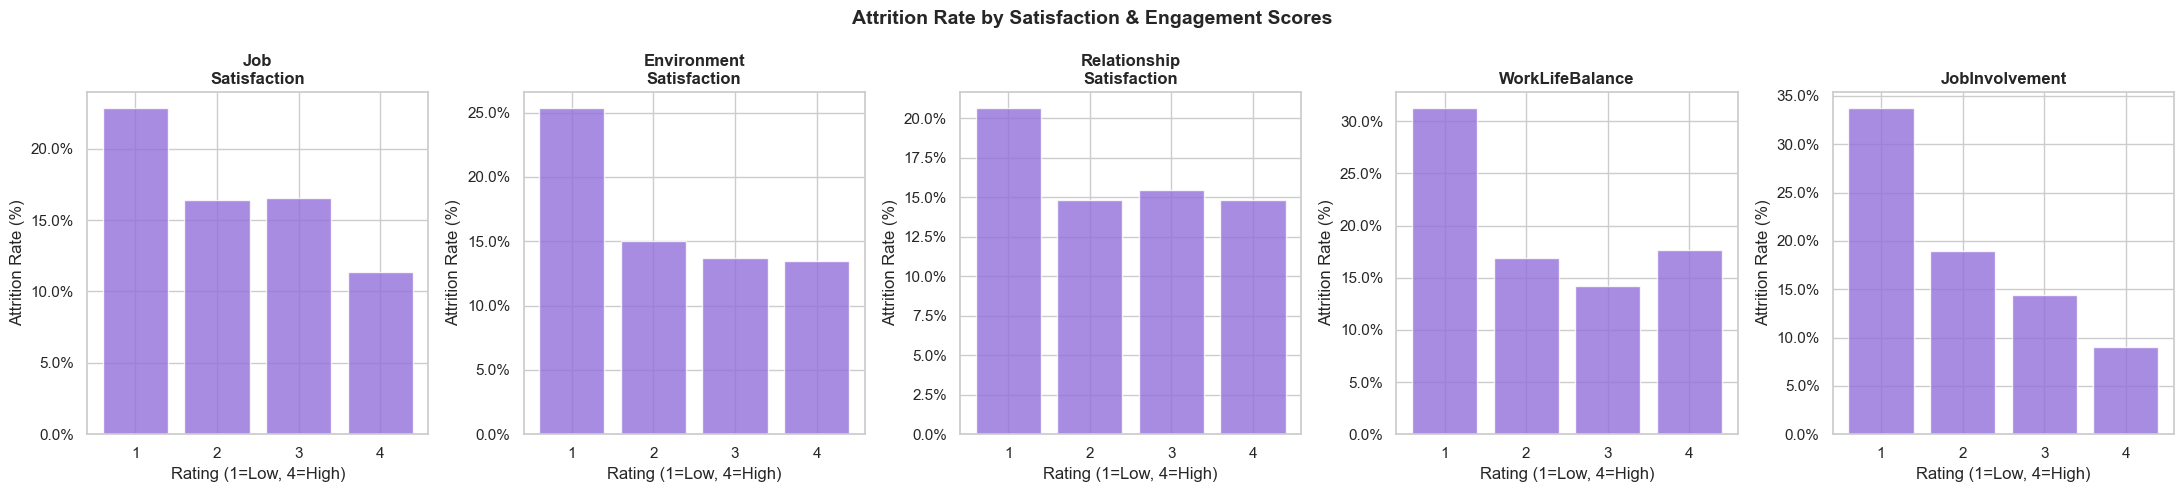

In [12]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(satisfaction_cols):
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    )
    axes[i].bar(attrition_rate.index.astype(str), attrition_rate.values,
                color='mediumpurple', alpha=0.8, edgecolor='white')
    axes[i].set_title(col.replace('Satisfaction', '\nSatisfaction'), fontweight='bold')
    axes[i].set_xlabel('Rating (1=Low, 4=High)')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Attrition Rate by Satisfaction & Engagement Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/attrition_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

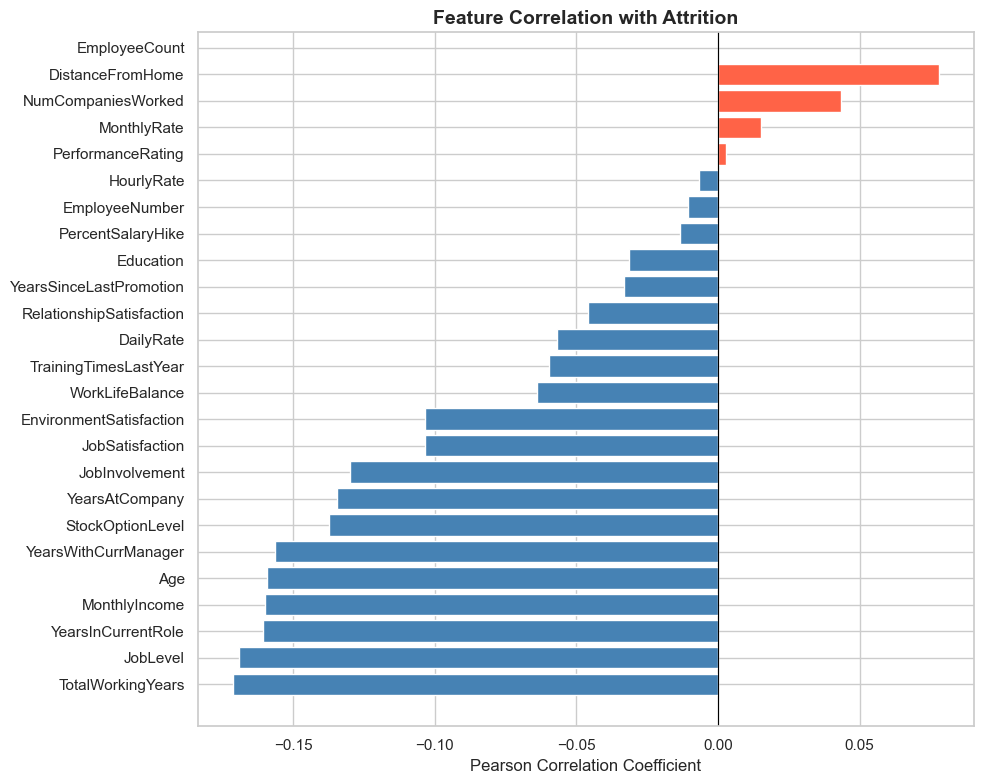

In [13]:
# Encode target for correlation
df_corr = df.copy()
df_corr['Attrition_num'] = (df_corr['Attrition'] == 'Yes').astype(int)

# Select only numeric columns
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# Correlation with target
corr_with_target = numeric_df.corr()['Attrition_num'].drop('Attrition_num').sort_values()

plt.figure(figsize=(10, 8))
colors = ['tomato' if x > 0 else 'steelblue' for x in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../data/correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary — Key Findings

1. **Class Imbalance**: 84% stayed vs 16% left — must be handled in modeling
2. **Top attrition drivers identified**:
   - OverTime (Yes) → dramatically higher attrition
   - Low MonthlyIncome → higher attrition
   - Young age & low YearsAtCompany → higher attrition
   - Low satisfaction scores (Job, Environment, Relationship) → higher attrition
   - Sales Representatives & HR roles → highest attrition by job role
3. **Useless columns found**: StandardHours, Over18, EmployeeCount, EmployeeNumber → will be dropped
4. **No missing values or duplicates** — dataset is clean
5. **Some numeric columns are ordinal** (Education, JobLevel, etc.) → will treat accordingly